# Hybrid Model: SOM + ANN for Fraud Detection


## 1. Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from minisom import MiniSom
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

2026-05-16 10:02:04.242827: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Loading Dataset

In [5]:
df = pd.read_csv('/Users/harmansingh/AI Engineering/Deep Learning/Self Organising Map (SOM)/Credit_Card_Applications.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (690, 16)


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


## 3. SOM — Unsupervised Fraud Detection
SOM maps high-dimensional data to a 2D grid. Nodes with high Mean Inter-Neuron Distance (MID) are anomalies — potential fraudsters.

In [12]:
# Features (excluding CustomerID at col 0) and target label
x = df.iloc[:, :-1].values   # all cols except last (approval flag)
y = df.iloc[:, -1].values    # approval: 1=approved, 0=rejected

# Feature Scaling for SOM
sc_som = MinMaxScaler()
x_scaled = sc_som.fit_transform(x)

In [14]:
# Training SOM
som = MiniSom(x=10, y=10, input_len=15, sigma=1.0, learning_rate=0.5)
som.random_weights_init(x_scaled)
som.train_random(data=x_scaled, num_iteration=100)
print('SOM training complete.')

SOM training complete.


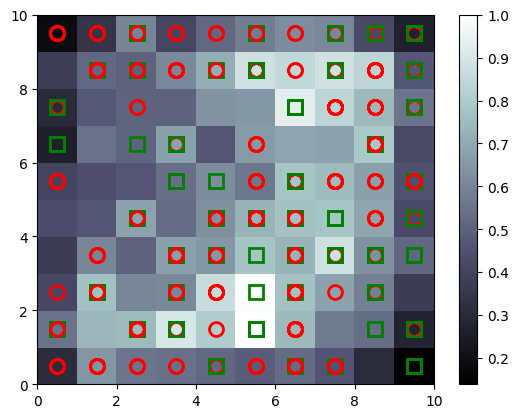

In [17]:
# Visualising SOM — U-Matrix
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors  = ['r', 'g']
for i, z in enumerate(x_scaled):
    w = som.winner(z)
    plot(w[0] + 0.5, w[1] + 0.5,
         markers[y[i]],
         markeredgecolor=colors[y[i]],
         markerfacecolor='None',
         markersize=10, markeredgewidth=2)
show()

In [19]:
# ---------------------------------------------------------------
# FRAUD EXTRACTION — Fixed approach
# We find which SOM nodes have high MID (bright = anomalous),
# then collect the original row INDICES that map to those nodes.
# ---------------------------------------------------------------

# Threshold: nodes above the 75th percentile of MID are suspicious
distance_map = som.distance_map()
threshold = np.percentile(distance_map, 75)

# Get (row, col) of suspicious nodes
suspicious_nodes = set(
    (r, c) for r in range(distance_map.shape[0])
             for c in range(distance_map.shape[1])
             if distance_map[r, c] > threshold
)

# Map each customer to their SOM winner node
is_fraud = np.array([
    1 if som.winner(x_scaled[i]) in suspicious_nodes else 0
    for i in range(len(x_scaled))
])

print(f'Suspected fraudsters: {is_fraud.sum()} / {len(is_fraud)}')

Suspected fraudsters: 204 / 690


## 4. ANN — Supervised Classification
We use SOM-derived fraud labels to train an ANN that assigns each customer a fraud probability.

In [23]:
# Feature matrix for ANN (all features except CustomerID)
customers = df.iloc[:, 1:].values

# Scale features
sc_ann = StandardScaler()
customers_scaled = sc_ann.fit_transform(customers)

# Train / Test split (80-20) — IMPORTANT for honest evaluation
X_train, X_test, y_train, y_test = train_test_split(
    customers_scaled, is_fraud,
    test_size=0.2, random_state=42, stratify=is_fraud
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Fraud rate in train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

Train size: 552 | Test size: 138
Fraud rate in train: 29.53% | test: 29.71%


In [25]:
# Build ANN
# NOTE: original had Dense(2) as first hidden layer — far too small.
# Increased to 16 units so the network can actually learn.
ann = Sequential([
    Dense(16, kernel_initializer='uniform', activation='relu', input_dim=15),
    Dropout(0.3),
    Dense(8,  kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.summary()

2026-05-16 10:02:52.664403: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-16 10:02:52.665026: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-16 10:02:52.665076: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-16 10:02:52.665388: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-16 10:02:52.665448: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                256       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dropout_1 (Dropout)         (None, 8)                 0         
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 401
Trainable params: 401
Non-trainable params: 0
_________________________________________________________________


In [27]:
# Train with Early Stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ann.fit(
    X_train, y_train,
    batch_size=8,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


2026-05-16 10:02:58.582670: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-16 10:02:58.631730: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_10.


62/62 [==============================] - 3s 8ms/step - loss: 0.6789 - accuracy: 0.6714 - val_loss: 0.6697 - val_accuracy: 0.6964
Epoch 2/100
12/62 [====>.........................] - ETA: 0s - loss: 0.6611 - accuracy: 0.7292

2026-05-16 10:03:01.566482: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


62/62 [==============================] - 0s 5ms/step - loss: 0.6558 - accuracy: 0.7077 - val_loss: 0.6467 - val_accuracy: 0.6964
Epoch 3/100
62/62 [==============================] - 0s 5ms/step - loss: 0.6267 - accuracy: 0.7056 - val_loss: 0.6101 - val_accuracy: 0.6964
Epoch 4/100
62/62 [==============================] - 0s 5ms/step - loss: 0.5983 - accuracy: 0.7298 - val_loss: 0.5807 - val_accuracy: 0.6786
Epoch 5/100
62/62 [==============================] - 0s 5ms/step - loss: 0.5676 - accuracy: 0.7319 - val_loss: 0.5652 - val_accuracy: 0.7143
Epoch 6/100
62/62 [==============================] - 0s 5ms/step - loss: 0.5540 - accuracy: 0.7520 - val_loss: 0.5578 - val_accuracy: 0.7679
Epoch 7/100
62/62 [==============================] - 0s 5ms/step - loss: 0.5552 - accuracy: 0.7681 - val_loss: 0.5520 - val_accuracy: 0.7857
Epoch 8/100
62/62 [==============================] - 0s 5ms/step - loss: 0.5478 - accuracy: 0.7581 - val_loss: 0.5524 - val_accuracy: 0.7679
Epoch 9/100
62/62 [======

## 5. Evaluation Metrics

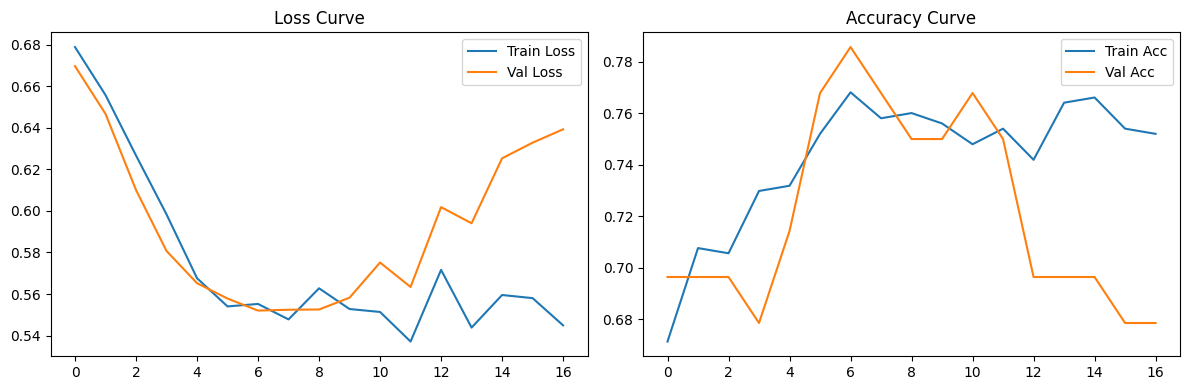

In [29]:
# --- Training history plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy Curve'); axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
# Predict probabilities and binarise at threshold 0.5
y_prob = ann.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print('\n========== Classification Report ==========')
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_prob)

print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')

1/5 [=====>........................] - ETA: 0s

2026-05-16 10:03:16.602169: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 0s 50ms/step

========== Classification Report ==========
              precision    recall  f1-score   support

       Legit       0.76      0.96      0.85        97
       Fraud       0.75      0.29      0.42        41

    accuracy                           0.76       138
   macro avg       0.76      0.63      0.64       138
weighted avg       0.76      0.76      0.72       138

Precision : 0.7500
Recall    : 0.2927
F1-Score  : 0.4211
ROC-AUC   : 0.7375


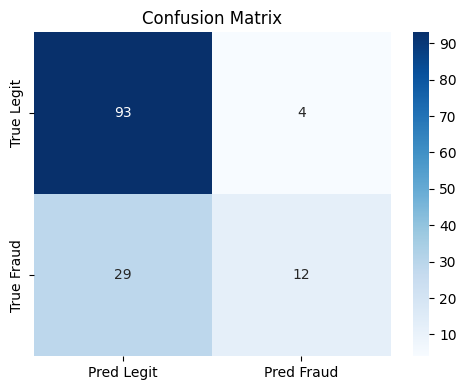

In [33]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['True Legit', 'True Fraud'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

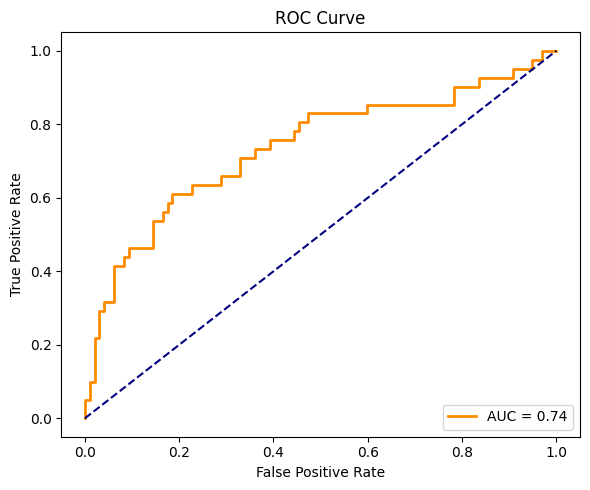

In [35]:
# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Predicting on Full Dataset (Ranked Output)

In [38]:
# Predict probabilities for all customers
all_probs = ann.predict(customers_scaled).flatten()

results = np.concatenate(
    (df.iloc[:, 0:1].values, all_probs.reshape(-1, 1)), axis=1
)

# Sort by fraud probability (highest first)
results = results[results[:, 1].argsort()[::-1]]

results_df = pd.DataFrame(results, columns=['CustomerID', 'FraudProbability'])
results_df['FraudProbability'] = results_df['FraudProbability'].round(4)
results_df['PredictedLabel']   = (results_df['FraudProbability'] >= 0.5).astype(int)

print(f"High-risk customers (prob >= 0.5): {(results_df['PredictedLabel']==1).sum()}")
print(results_df.head(20).to_string(index=False))

22/22 [==============================] - 0s 4ms/step
High-risk customers (prob >= 0.5): 97
 CustomerID  FraudProbability  PredictedLabel
 15790113.0            0.9317               1
 15623210.0            0.7440               1
 15638983.0            0.7409               1
 15617991.0            0.6954               1
 15654625.0            0.6909               1
 15662854.0            0.6816               1
 15627328.0            0.6807               1
 15641007.0            0.6780               1
 15750104.0            0.6773               1
 15632503.0            0.6725               1
 15643056.0            0.6646               1
 15745375.0            0.6591               1
 15665014.0            0.6450               1
 15570508.0            0.6413               1
 15673747.0            0.6383               1
 15569917.0            0.6250               1
 15802869.0            0.6245               1
 15750545.0            0.6237               1
 15680901.0            0.6221      